### Получаем данные

In [1]:
from src.mlcore.dataloader import get_processed_data

raw = get_processed_data(
    source="raw",
    symbol="BTCUSDC",
    drop_last=True,
    save_dir="parquets/",
    grid_resolution_ms=5000,
)
raw

orderbook_snapshots: 100%|██████████| 42/42 [00:49<00:00,  1.18s/it]


,exchange_ts,open,high,low,close,volume,volume_1s,buy_volume_1s,sell_volume_1s,volume_imbalance_1s,...,ask_qty_90,ask_qty_91,ask_qty_92,ask_qty_93,ask_qty_94,ask_qty_95,ask_qty_96,ask_qty_97,ask_qty_98,ask_qty_99
0,2026-01-23 11:50:30,89130.601562,89139.500000,89130.500000,89135.101562,0.769,0.000,0.000,0.000,0.000000,...,0.014,1.000,0.139,0.002,0.005,0.141,1.796,0.821,0.006,0.139
1,2026-01-23 11:50:35,89130.398438,89130.398438,89130.398438,89130.398438,0.002,0.196,0.000,0.196,-1.000000,...,0.139,0.002,0.139,0.744,0.139,1.010,1.796,0.139,0.112,1.139
2,2026-01-23 11:50:40,89130.398438,89130.398438,89130.398438,89130.398438,0.002,0.000,0.000,0.000,0.000000,...,0.020,0.023,0.139,1.094,0.139,1.075,1.796,0.139,1.008,1.139
3,2026-01-23 11:50:45,89130.398438,89130.398438,89128.000000,89128.101562,0.232,0.000,0.000,0.000,0.000000,...,0.002,0.139,1.094,0.139,1.122,1.796,0.139,1.011,0.112,1.307
4,2026-01-23 11:50:50,89128.101562,89128.101562,89128.101562,89128.101562,0.002,0.004,0.000,0.004,-1.000000,...,0.005,0.139,0.415,0.003,0.139,0.004,0.139,0.978,0.139,0.744
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1067869,2026-03-26 06:59:35,70027.000000,70030.000000,70019.296875,70025.101562,4.655,0.003,0.000,0.003,-1.000000,...,0.040,0.632,0.017,0.003,0.006,0.002,0.911,0.284,0.014,0.040
1067870,2026-03-26 06:59:40,70047.296875,70048.898438,70025.101562,70038.898438,3.599,4.652,4.331,0.321,0.861995,...,0.017,0.207,0.035,0.099,0.002,0.003,0.284,0.006,1.315,0.010
1067871,2026-03-26 06:59:45,70028.000000,70036.500000,70024.000000,70029.398438,1.762,0.284,0.000,0.284,-1.000000,...,0.139,0.002,0.142,0.014,0.221,1.315,0.006,0.320,0.006,0.025
1067872,2026-03-26 06:59:50,70020.101562,70027.000000,70020.101562,70020.703125,0.235,1.087,0.000,1.087,-1.000000,...,1.308,0.002,0.020,0.002,0.002,0.011,0.207,0.022,0.068,0.599


### Определяем таргеты для всех моделей

In [2]:
import numpy as np
import pandas as pd
from tqdm import tqdm


def calculate_mid_target(df: pd.DataFrame):
    target = np.zeros(len(df), dtype=float)
    for i in tqdm(range(len(df) - 1)):
        current = df['close'].iloc[i]
        mid = (df['high'].iloc[i+1] + df['low'].iloc[i+1]) / 2.0
        target[i] = np.log(mid / current)
    return pd.Series(target, index=df.index)


def calculate_spread_target(df: pd.DataFrame):
    target = np.zeros(len(df), dtype=float)
    for i in tqdm(range(len(df) - 1)):
        current = df['close'].iloc[i]
        spread = df['high'].iloc[i+1] - df['low'].iloc[i+1]
        target[i] = spread / current
    return pd.Series(target, index=df.index)


mid_target = calculate_mid_target(raw)
spread_target = calculate_spread_target(raw)

100%|██████████| 1067873/1067873 [00:09<00:00, 114092.40it/s]


### Генерируем фичи для всех моделей

In [3]:
from src.mlcore.dataloader import calculate_features

df = calculate_features(raw, filename='all_features')
df['low'] = raw['low']
df['high'] = raw['high']
df['close'] = raw['close']
df['mid_target'] = mid_target
df['spread_target'] = spread_target
df.dropna(inplace=True)
df

,adverse_selection_risk,ask_price_pressure,atr,atr_exponential_smoothing_alpha_0_8,bid_ask_cancellation_proxy5,bid_ask_spread_tightness_index,bid_price_pressure,combo16_weighted_orderbook_log_times_slope,combo29_response_imbalance_log1p_times_wli,combo35_fqi_rolling_std_18_times_slope,...,volatility_contraction_expansion_ratio,weighted_depth_ratio,weighted_log_imbalance_5levels,weighted_orderbook_imbalance,weighted_price_pressure,low,high,close,mid_target,spread_target
30,1.720052,4.470000,4.350781,4.826048,0.000159,1.720241,0.399000,-0.282542,-0.043540,-3.870383,...,0.149335,0.862152,-0.825813,-0.537971,-0.540668,89142.398438,89150.796875,89145.703125,0.000001,0.000000
31,1.673307,0.248484,4.208880,4.584924,0.000214,1.673463,0.588047,3.569189,0.434759,32.839458,...,0.141798,4.493296,4.811982,0.943113,0.945398,89145.796875,89145.796875,89145.796875,0.000000,0.000000
32,1.826563,0.965219,4.068584,4.278148,0.000275,1.826706,0.176813,2.594957,0.397548,28.002368,...,0.141798,3.452995,3.723537,0.751790,0.752639,89145.796875,89145.796875,89145.796875,0.000000,0.000000
33,1.826563,0.026508,3.932965,3.976710,0.000443,1.826679,0.055969,0.989410,0.123907,17.214146,...,0.138072,2.117040,2.170741,0.394916,0.393676,89145.796875,89145.796875,89145.796875,0.000051,0.000001
34,1.788281,0.026914,3.955251,3.956434,0.000956,1.788374,0.056250,0.976829,0.122001,16.139879,...,0.145653,2.066252,2.160544,0.390597,0.389091,89150.296875,89150.398438,89150.398438,0.000020,0.000039
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1067869,4.229557,1.047656,7.822695,7.849500,0.000067,4.229545,0.023562,-0.441990,-0.269600,-5.840528,...,0.257246,0.583593,-1.184085,-0.573829,-0.585472,70019.296875,70030.000000,70025.101562,0.000170,0.000340
1067870,4.586198,0.330000,8.355168,8.795999,0.000031,4.586184,1.547109,2.014850,0.736749,25.511341,...,0.283893,2.728301,3.068821,0.663342,0.676572,70025.101562,70048.898438,70038.898438,-0.000123,0.000178
1067871,4.659635,0.438750,8.573277,9.320488,0.000019,4.659622,0.231750,-2.258261,-0.924529,-26.176059,...,0.303619,0.391767,-3.464226,-0.756381,-0.761847,70024.000000,70036.500000,70029.398438,-0.000084,0.000099
1067872,5.036328,0.281000,8.597397,9.416544,0.000042,5.036313,0.989180,2.644685,0.788771,39.358872,...,0.316982,1.713700,4.180185,0.603121,0.593770,70020.101562,70027.000000,70020.703125,0.000241,0.000414


In [4]:
feature_columns = [col for col in df.columns if col not in ['mid_target', 'spread_target', 'close', 'high', 'low']]
X = df[feature_columns].copy()
y_mid = df['mid_target'].copy()
y_spread = df['spread_target'].copy()
ohlcv = df[['close', 'high', 'low']].copy()

split_index = int(len(X) * 0.75)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_mid_train, y_mid_test = y_mid.iloc[:split_index], y_mid.iloc[split_index:]
y_spread_train, y_spread_test = y_spread.iloc[:split_index], y_spread.iloc[split_index:]
_, ohlcv_test = ohlcv.iloc[:split_index], ohlcv.iloc[split_index:]

### Обучаем mid model

In [5]:
from src.mlcore.train import train_regression_model

mid_model = train_regression_model(
    X_train=X_train,
    y_train=y_mid_train,
    X_test=X_test,
    y_test=y_mid_test,
    n_estimators=5000,
    objective='reg:squarederror',
    model_name="model_mid",
    max_depth=13,
)

Обучение модели...
[0]	validation_0-rmse:0.00017
[50]	validation_0-rmse:0.00016
[100]	validation_0-rmse:0.00015
[150]	validation_0-rmse:0.00015
[200]	validation_0-rmse:0.00015
[250]	validation_0-rmse:0.00015
[300]	validation_0-rmse:0.00015
[350]	validation_0-rmse:0.00015
[400]	validation_0-rmse:0.00015
[450]	validation_0-rmse:0.00015
[500]	validation_0-rmse:0.00015
[550]	validation_0-rmse:0.00015
[600]	validation_0-rmse:0.00015
[650]	validation_0-rmse:0.00015
[700]	validation_0-rmse:0.00015
[744]	validation_0-rmse:0.00015
Модель сохранена в директорию: models/model_mid.json


MAE                      : 0.000090
RMSE                     : 0.000148
R²                       : 0.277962
MAE / mean|Δ|            : 0.817731
RMSE / RMSE_base         : 0.849712
mean|Δ| (target)         : 0.000111

------------------------------------------------------------
Directional Accuracy     : 0.636336
Target Pos Ratio         : 0.473444
Profit Factor            : 1.802201
Avg Gain (correct)       : -0.000004
Avg Loss (incorrect)     : 0.000004

------------------------------------------------------------
Binomial p-value (vs 50%)     : 0.000000
Directional Acc 95% CI        : (0.6346, 0.6382)
Is Significant (α=5%)         : True

📊 Квантильный анализ (топ-3 квантиля по уверенности):
            quantile  confidence  directional_acc  mean_return  n_samples
 (0.000118, 0.00168]    0.000216         0.922573    -0.000006      26696
(6.47e-05, 0.000118]    0.000087         0.818962    -0.000002      26696
(4.11e-05, 6.47e-05]    0.000052         0.738875    -0.000002      26696


/Users/honeysuckle/dev/AlgoTradingSystem_c1/src/mlcore/evaluation.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for q, group in df.groupby('quantile'):


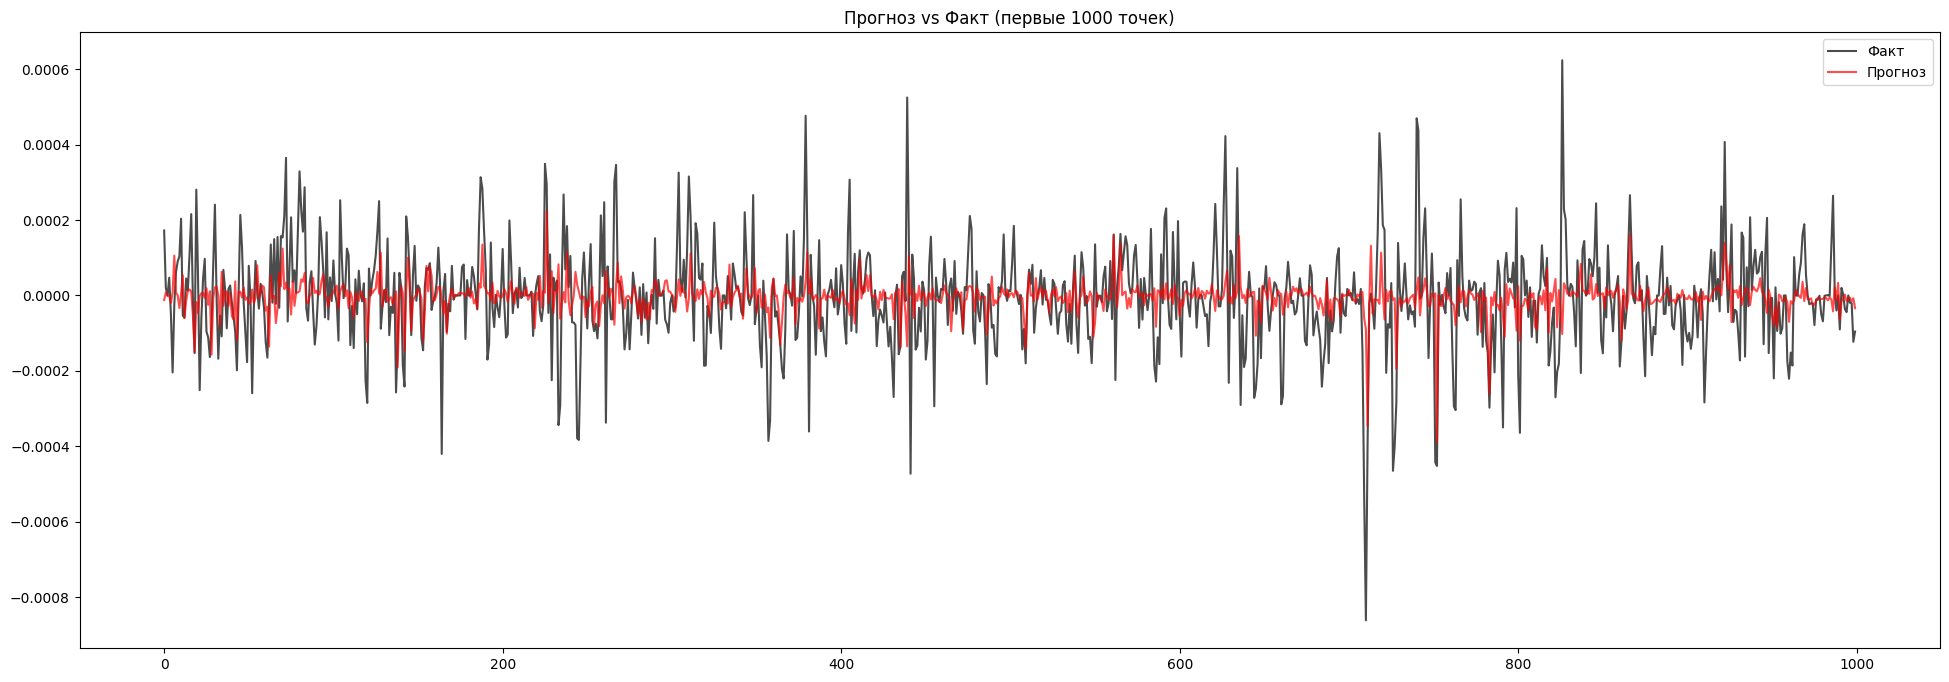

In [6]:
from src.mlcore.evaluation import evaluate_regression_model

y_mid_pred = mid_model.predict(X_test)

evaluate_regression_model(
    y_test=y_mid_test,
    y_pred=y_mid_pred,
    length=1000,
)

### Обучаем spread model

In [7]:
from src.mlcore.train import train_regression_model

spread_model = train_regression_model(
    X_train=X_train,
    y_train=y_spread_train,
    X_test=X_test,
    y_test=y_spread_test,
    n_estimators=5000,
    objective='reg:squaredlogerror',
    model_name="model_spread",
    max_depth=8,
)

Обучение модели...
[0]	validation_0-rmse:0.00020
[50]	validation_0-rmse:0.00017
[100]	validation_0-rmse:0.00016
[150]	validation_0-rmse:0.00015
[200]	validation_0-rmse:0.00015
[250]	validation_0-rmse:0.00015
[300]	validation_0-rmse:0.00015
[350]	validation_0-rmse:0.00015
[400]	validation_0-rmse:0.00015
[450]	validation_0-rmse:0.00015
[500]	validation_0-rmse:0.00015
[550]	validation_0-rmse:0.00015
[600]	validation_0-rmse:0.00015
[650]	validation_0-rmse:0.00015
[700]	validation_0-rmse:0.00015
[750]	validation_0-rmse:0.00015
[800]	validation_0-rmse:0.00015
[806]	validation_0-rmse:0.00015
Модель сохранена в директорию: models/model_spread.json


MAE                      : 0.000098
RMSE                     : 0.000147
R²                       : 0.403055
MAE / mean|Δ|            : 0.607326
RMSE / RMSE_base         : 0.590544
mean|Δ| (target)         : 0.000161

------------------------------------------------------------
Directional Accuracy     : 0.888373
Target Pos Ratio         : 0.888373
Profit Factor            : 42982148550.499229
Avg Gain (correct)       : 0.000181
Avg Loss (incorrect)     : 0.000000

------------------------------------------------------------
Binomial p-value (vs 50%)     : 0.000000
Directional Acc 95% CI        : (0.8872, 0.8895)
Is Significant (α=5%)         : True

📊 Квантильный анализ (топ-3 квантиля по уверенности):
           quantile  confidence  directional_acc  mean_return  n_samples
 (0.000314, 0.0029]    0.000437         0.999813     0.000432      26696
(0.00023, 0.000314]    0.000267         0.994606     0.000263      26696
(0.000186, 0.00023]    0.000207         0.981046     0.000200      26

/Users/honeysuckle/dev/AlgoTradingSystem_c1/src/mlcore/evaluation.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for q, group in df.groupby('quantile'):


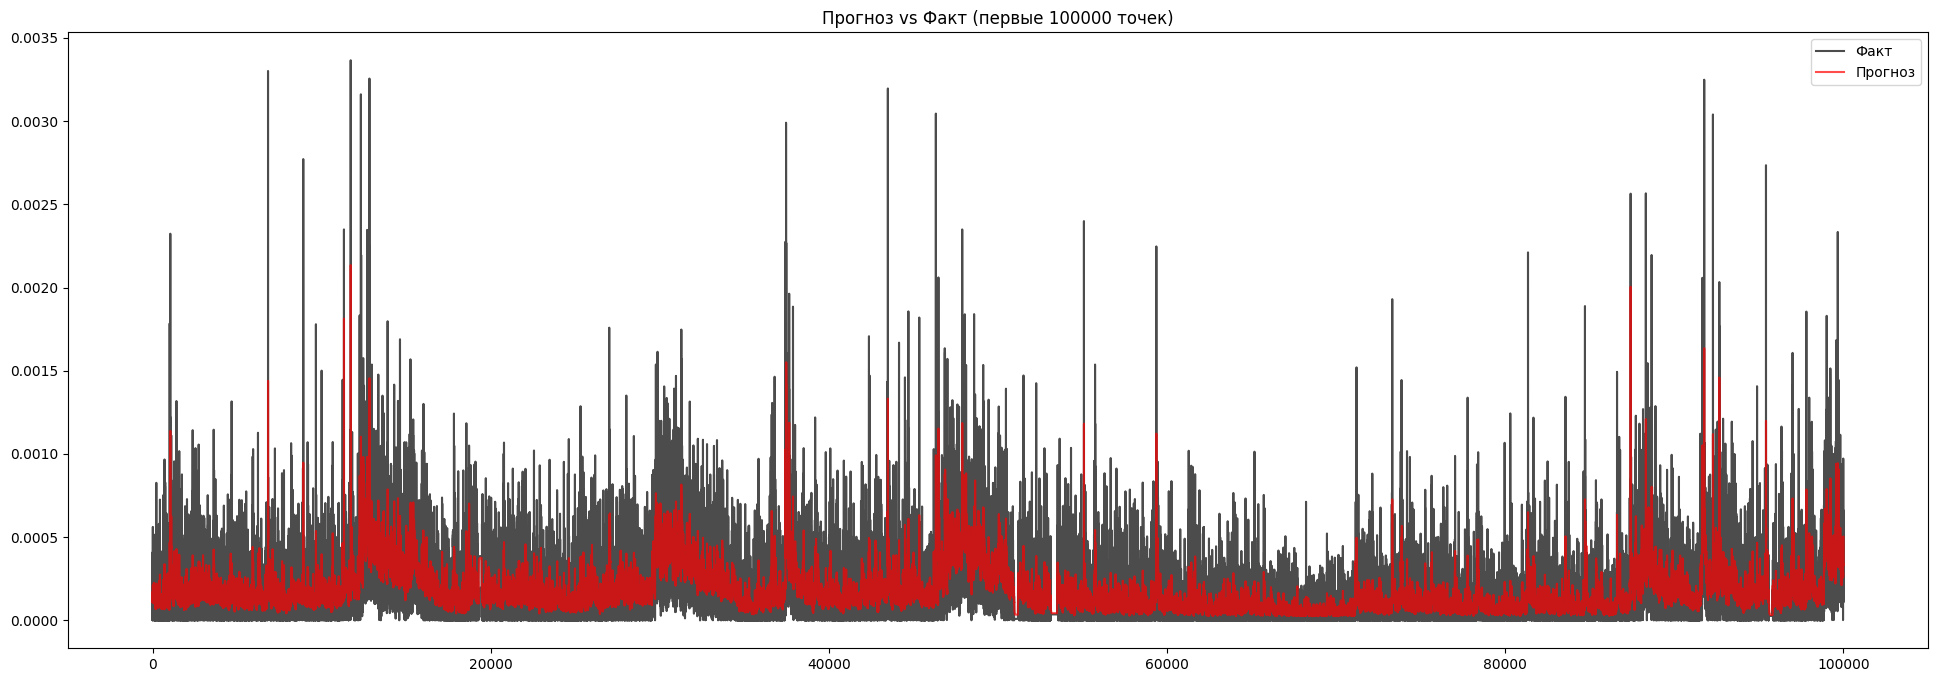

In [8]:
from src.mlcore.evaluation import evaluate_regression_model

y_spread_pred = spread_model.predict(X_test)

evaluate_regression_model(
    y_test=y_spread_test,
    y_pred=y_spread_pred,
    length=100000,
)